In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.sparse.linalg import LinearOperator, aslinearoperator
import sys

In [2]:
def create_grayscale_circle(size=128, radius=50, tol=1e-3):
    """
    Creates a grayscale image of a circle.

    Args:
        size (int): The width and height of the square image.
        radius (int): The radius of the circle.

    Returns:
        numpy.ndarray: A 2D NumPy array representing the grayscale image.
    """
    # Create a white 2D array for the image
    image_array = np.ones((size, size), dtype=np.uint8) * 255

    # Calculate the center of the image
    center = size // 2

    # Iterate over each pixel and check if it's within the circle's radius
    for y in range(size):
        for x in range(size):
            # Calculate the distance from the center
            distance = np.sqrt((x - center) ** 2 + (y - center) ** 2)
            
            # If the distance is less than or equal to the radius, make the pixel white
            if np.isclose(distance, radius, atol=tol):
                image_array[y, x] = 0  # 0 for black in a grayscale image

    return image_array

(128, 128)

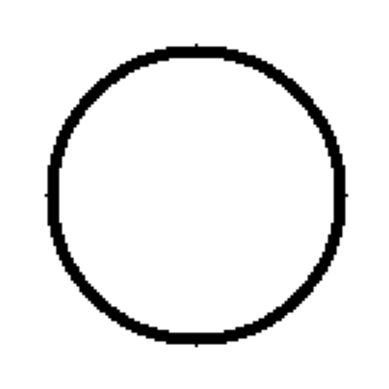

In [3]:
image = create_grayscale_circle(tol=2) # RGB image
plt.imshow(image, cmap="gray")
plt.axis("off")
image.shape
#plt.savefig("coins.png")

In [4]:
def gaussian_kernel(size=7, sigma=1.0):
    """
    Creates a 2D Gaussian kernel.

    size : int (must be odd) -> dimension of the kernel (size x size)
    sigma: float -> standard deviation of the Gaussian
    """
    # Make a coordinate grid centered at 0
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / np.sum(kernel)  # normalize
    return kernel

kernel = gaussian_kernel(size=7, sigma=2.5)

In [5]:
def make_blur_operator(kernel, image_shape, boundary="zero"):
    """
    Return A as a LinearOperator that applies convolution with kernel
    (mode='same') to an image flattened as a vector.
    
    kernel         : 2D numpy array (blur kernel)
    image_shape : (h, w) tuple
    boundary    : 'zero' or 'symm'
    """
    h, w = image_shape
    N = h * w
    kernel_flipped = np.flipud(np.fliplr(kernel))  # needed for transpose (A^T)

    def matvec(x_vec):
        x = x_vec.reshape(h, w)
        y = convolve2d(x, kernel, mode="same",
                       boundary="fill" if boundary=="zero" else "symm",
                       fillvalue=0.0)
        return y.ravel()

    def rmatvec(y_vec):
        y = y_vec.reshape(h, w)
        x = convolve2d(y, kernel_flipped, mode="same",
                       boundary="fill" if boundary=="zero" else "symm",
                       fillvalue=0.0)
        return x.ravel()

    return LinearOperator((N, N), matvec=matvec, rmatvec=rmatvec, dtype=np.float64)

A = make_blur_operator(kernel, image.shape)

(128, 128)

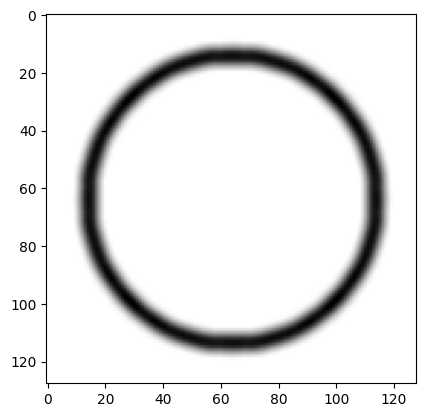

In [6]:
blurred = convolve2d(image, kernel, mode="same", boundary="symm")
plt.imshow(blurred, cmap="gray")
blurred.shape

In [7]:
# Memory
A_bytes = sys.getsizeof(A)
print("A takes", A_bytes , "bytes")

A takes 48 bytes


In [8]:
def find_solution(x: np.ndarray, b: np.ndarray, A: np.ndarray, noise: float=0, lam: float=0, tol: float=1e-6, max_iter: int=1000):   
    # Vectorize
    x_true = x.copy().ravel()
    _A = A.T @ A + aslinearoperator(lam*np.eye(x_true.size))
    _b = (A.T @ b.ravel())

    # add error
    rng = np.random.default_rng(0)
    noise_v = rng.standard_normal(_b.shape) * noise
    _b += noise_v

    # SD Method
    xi = np.zeros_like(x_true)
    

    for _ in range(1, max_iter+1):

        ri = _b - _A @ xi
        ai = (ri.T @ ri) / (ri.T @ A @ ri)
        xi = xi + ai * ri

        if np.all(ri < tol):
            break

    deblurred = xi.reshape(image.shape)

    # Check reconstruction error
    err = np.linalg.norm(xi - x_true) / np.linalg.norm(x_true)
    print(f"Relative reconstruction error: {err:.3e}")

    return deblurred, _


Relative reconstruction error: 2.550e-01
Took 604 iterations


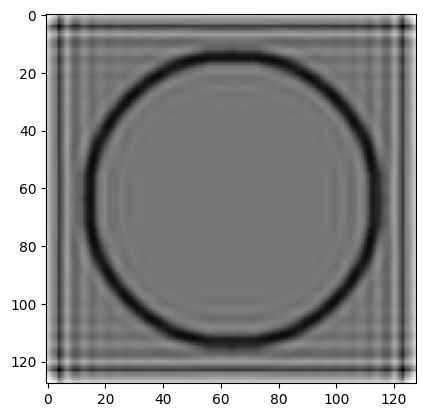

In [9]:
noiseless_solution, iters = find_solution(image, blurred, A, lam=0.01)
print("Took", iters, "iterations")
plt.imshow(noiseless_solution, cmap="gray")

Relative reconstruction error: 2.125e-01
Took 47 iterations


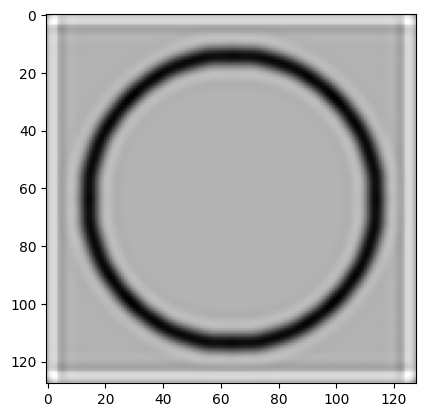

In [10]:
noisy_solution, iters = find_solution(image, blurred, A, noise=1e-2, lam=0.2)
print("Took", iters, "iterations")
plt.imshow(noisy_solution, cmap="gray")